# 06 — Tensor construction: T3 spectral + NASA POWER climate deltas for M5B

**Project:** `Barranquilla_LST_2013_2026_Modeling`  
**Repository notebook:** `notebooks/06_tensor_construction.ipynb`  
**Operational period:** 2013–2025  
**Target years:** 2016–2025  
**Tensor formulation:** `T3_M5B_spectral_nasa_power`

## Purpose

Build full-domain tensors for the final M5B formulation:

```text
X(Y) = [spectral indices from Y-3, Y-2, Y-1] + [NASA POWER climate deltas for Y]
y(Y) = LST_norm(Y)
mask(Y) = valid temporal land-domain sample mask
```

The tensor contains:

```text
18 spectral channels = 3 antecedent years × 6 Landsat spectral indices
 2 climate channels  = NASA POWER interannual deltas replicated spatially
20 total input channels
```

NASA POWER variables are **not interpreted as pixel-wise climate rasters**. They are annual regional descriptors associated with the model-domain centroid. They are expanded as constant spatial layers only to make them compatible with convolutional tensor inputs.

## GitHub policy

The generated `.npz` tensors and raster masks are model inputs and can be large. They should stay in Google Drive. Only lightweight CSV/JSON/Markdown reports should be uploaded to GitHub under `data/tensors/`.


In [1]:
# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
# ============================================================
# CELL 2 — Imports and official paths
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import re
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.errors import NotGeoreferencedWarning
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)
pd.set_option("display.max_columns", 120)

PROJECT_DIR = Path("/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling")
MODEL_DOMAIN_REFERENCE = PROJECT_DIR / "01_aoi_reference" / "reference_grid" / "model_domain_reference.tif"
NORMALIZED_DIR = PROJECT_DIR / "05_normalized_products" / "v6_train_only_mixed_strategy"
DOC05_DIR = PROJECT_DIR / "00_documentation" / "quality_control" / "05_climate_forcing_integration_2013_2025"
CLIMATE_SELECTED_CSV = DOC05_DIR / "05_model_climate_inputs_selected_m5b_2016_2025.csv"

TENSOR_ROOT = PROJECT_DIR / "06_model_inputs" / "tensors" / "T3_M5B_spectral_nasa_power"
TENSOR_NPZ_DIR = TENSOR_ROOT / "npz"
TENSOR_MASK_DIR = PROJECT_DIR / "06_model_inputs" / "valid_model_masks" / "T3_M5B_spectral_nasa_power"
DOC06_DIR = PROJECT_DIR / "00_documentation" / "quality_control" / "06_tensor_construction_2016_2025"
DOC06_FIG_DIR = DOC06_DIR / "figures"

for d in [TENSOR_NPZ_DIR, TENSOR_MASK_DIR, DOC06_DIR, DOC06_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

required_paths = {
    "PROJECT_DIR": PROJECT_DIR,
    "MODEL_DOMAIN_REFERENCE": MODEL_DOMAIN_REFERENCE,
    "NORMALIZED_DIR": NORMALIZED_DIR,
    "DOC05_DIR": DOC05_DIR,
    "CLIMATE_SELECTED_CSV": CLIMATE_SELECTED_CSV,
}
missing = {k: str(v) for k, v in required_paths.items() if not v.exists()}
if missing:
    raise FileNotFoundError("Missing required paths:\n" + json.dumps(missing, indent=2, ensure_ascii=False))

print("PROJECT_DIR          :", PROJECT_DIR)
print("MODEL_DOMAIN_REFERENCE:", MODEL_DOMAIN_REFERENCE)
print("NORMALIZED_DIR       :", NORMALIZED_DIR)
print("CLIMATE_SELECTED_CSV :", CLIMATE_SELECTED_CSV)
print("TENSOR_ROOT          :", TENSOR_ROOT)
print("DOC06_DIR            :", DOC06_DIR)


PROJECT_DIR          : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
MODEL_DOMAIN_REFERENCE: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/01_aoi_reference/reference_grid/model_domain_reference.tif
NORMALIZED_DIR       : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/05_normalized_products/v6_train_only_mixed_strategy
CLIMATE_SELECTED_CSV : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_model_climate_inputs_selected_m5b_2016_2025.csv
TENSOR_ROOT          : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/tensors/T3_M5B_spectral_nasa_power
DOC06_DIR            : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025


In [3]:
# ============================================================
# CELL 3 — Experimental design and channel schema
# ============================================================

SPECTRAL_VARIABLES = ["NDVI", "NDMI", "NDBI", "UI", "SAVI", "BSI"]
TARGET_VARIABLE = "LST"
LAGS = [3, 2, 1]

TARGET_YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
TRAIN_YEARS = [2016, 2017, 2018, 2019]
VALIDATION_YEARS = [2020, 2021, 2022]
TEST_YEARS = [2023, 2024, 2025]
SPLITS = {"train": TRAIN_YEARS, "validation": VALIDATION_YEARS, "test": TEST_YEARS}
YEAR_TO_SPLIT = {year: split for split, years in SPLITS.items() for year in years}

CLIMATE_VARIABLES_RAW = [
    "delta_t2m_mean_Y_minus_Yminus1",
    "delta_solar_radiation_mean_Y_minus_Yminus1",
]
SPECTRAL_CHANNEL_NAMES = [f"{var}_Yminus{lag}" for lag in LAGS for var in SPECTRAL_VARIABLES]
CLIMATE_CHANNEL_NAMES = [
    "clim_delta_t2m_mean_Y_minus_Yminus1_ztrain",
    "clim_delta_solar_radiation_mean_Y_minus_Yminus1_ztrain",
]
CHANNEL_NAMES = SPECTRAL_CHANNEL_NAMES + CLIMATE_CHANNEL_NAMES

assert len(SPECTRAL_CHANNEL_NAMES) == 18
assert len(CLIMATE_CHANNEL_NAMES) == 2
assert len(CHANNEL_NAMES) == 20

channel_schema_df = pd.DataFrame([
    {
        "channel_index": idx,
        "channel_name": name,
        "channel_group": "spectral_T3" if idx < 18 else "climate_NASA_POWER",
        "source": "Landsat normalized annual raster" if idx < 18 else "NASA POWER annual regional descriptor",
        "spatial_interpretation": "pixel-wise raster" if idx < 18 else "constant spatial layer replicated from annual regional value",
    }
    for idx, name in enumerate(CHANNEL_NAMES)
])
channel_schema_path = DOC06_DIR / "06_tensor_channel_schema_T3_M5B_2016_2025.csv"
channel_schema_df.to_csv(channel_schema_path, index=False)

print("Target years:", TARGET_YEARS)
print("Splits:", SPLITS)
print("Total channels:", len(CHANNEL_NAMES))
display(channel_schema_df)


Target years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Splits: {'train': [2016, 2017, 2018, 2019], 'validation': [2020, 2021, 2022], 'test': [2023, 2024, 2025]}
Total channels: 20


,channel_index,channel_name,channel_group,source,spatial_interpretation
0,0,NDVI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
1,1,NDMI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
2,2,NDBI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
3,3,UI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
4,4,SAVI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
5,5,BSI_Yminus3,spectral_T3,Landsat normalized annual raster,pixel-wise raster
6,6,NDVI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
7,7,NDMI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
8,8,NDBI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster
9,9,UI_Yminus2,spectral_T3,Landsat normalized annual raster,pixel-wise raster


In [4]:
# ============================================================
# CELL 4 — Reference geometry and file discovery utilities
# ============================================================

with rasterio.open(MODEL_DOMAIN_REFERENCE) as src:
    REFERENCE_PROFILE = src.profile.copy()
    REFERENCE_SHAPE = (src.height, src.width)
    REFERENCE_CRS = src.crs
    REFERENCE_TRANSFORM = src.transform

print("Reference CRS      :", REFERENCE_CRS)
print("Reference shape    :", REFERENCE_SHAPE)
print("Reference transform:", REFERENCE_TRANSFORM)

if REFERENCE_SHAPE != (1115, 1257):
    raise RuntimeError(f"Unexpected model-domain reference shape: {REFERENCE_SHAPE}; expected (1115, 1257).")


def list_tifs(base_dir: Path):
    return sorted(list(base_dir.rglob("*.tif")) + list(base_dir.rglob("*.tiff")))

NORMALIZED_TIFS = list_tifs(NORMALIZED_DIR)
print("Normalized GeoTIFFs found:", len(NORMALIZED_TIFS))
if not NORMALIZED_TIFS:
    raise RuntimeError(f"No normalized GeoTIFF files found in {NORMALIZED_DIR}")


def has_year(path: Path, year: int) -> bool:
    return re.search(rf"(?<!\d){year}(?!\d)", path.name) is not None


def has_variable_token(path: Path, var: str) -> bool:
    name = path.name.upper()
    var = var.upper()
    return re.search(rf"(^|[^A-Z0-9]){re.escape(var)}([^A-Z0-9]|$)", name) is not None


def resolve_single_normalized_product(var: str, year: int) -> Path:
    candidates = []
    for p in NORMALIZED_TIFS:
        name_upper = p.name.upper()
        if not has_year(p, year):
            continue
        if "N_OBS" in name_upper or "NOBS" in name_upper:
            continue
        if has_variable_token(p, var):
            candidates.append(p)

    if len(candidates) == 0:
        raise FileNotFoundError(f"No normalized product found for var={var}, year={year}")

    if len(candidates) > 1:
        preferred = [p for p in candidates if any(tok in p.name.upper() for tok in ["NORM", "NORMALIZED", "ZSCORE", "Z_SCORE", "ROBUST"])]
        if len(preferred) == 1:
            return preferred[0]
        msg = "\n".join(str(p) for p in candidates)
        raise RuntimeError(f"Ambiguous normalized product for var={var}, year={year}:\n{msg}")

    return candidates[0]

for var in ["NDVI", "LST"]:
    p = resolve_single_normalized_product(var, 2016)
    print(f"Resolved {var} 2016 ->", p.name)


Reference CRS      : EPSG:32618
Reference shape    : (1115, 1257)
Reference transform: | 30.00, 0.00, 495735.00|
| 0.00,-30.00, 1230045.00|
| 0.00, 0.00, 1.00|
Normalized GeoTIFFs found: 126
Resolved NDVI 2016 -> EXP10C_NDVI_robust01_train_2016.tif
Resolved LST 2016 -> EXP10C_LST_zscore_train_2016.tif


In [5]:
# ============================================================
# CELL 5 — Load NASA POWER selected variables and apply train-only z-score
# ============================================================

climate_df = pd.read_csv(CLIMATE_SELECTED_CSV)
climate_df.columns = [c.strip() for c in climate_df.columns]

if "target_year" not in climate_df.columns:
    possible_year_cols = [c for c in climate_df.columns if c.lower() in {"year", "target", "target_y", "y"}]
    if len(possible_year_cols) == 1:
        climate_df = climate_df.rename(columns={possible_year_cols[0]: "target_year"})
    else:
        raise RuntimeError(f"Climate CSV needs target_year column. Found columns: {list(climate_df.columns)}")

climate_df["target_year"] = climate_df["target_year"].astype(int)
missing_climate_cols = [c for c in CLIMATE_VARIABLES_RAW if c not in climate_df.columns]
if missing_climate_cols:
    raise RuntimeError("Missing selected climate variables: " + ", ".join(missing_climate_cols))

climate_df = climate_df[climate_df["target_year"].isin(TARGET_YEARS)].copy()
if sorted(climate_df["target_year"].tolist()) != TARGET_YEARS:
    raise RuntimeError(f"Climate selected table does not contain exactly 2016–2025. Found: {sorted(climate_df['target_year'].tolist())}")

climate_df["split"] = climate_df["target_year"].map(YEAR_TO_SPLIT)

climate_scaler = {"scaler_type": "z_score_train_only", "train_years": TRAIN_YEARS, "variables": {}}
train_clim = climate_df[climate_df["target_year"].isin(TRAIN_YEARS)].copy()
for raw_var in CLIMATE_VARIABLES_RAW:
    values = train_clim[raw_var].astype(float).to_numpy()
    mean_train = float(np.nanmean(values))
    std_train = float(np.nanstd(values, ddof=0))
    if not np.isfinite(std_train) or std_train == 0:
        raise RuntimeError(f"Invalid train std for climate variable {raw_var}: {std_train}")
    z_col = raw_var + "_ztrain"
    climate_df[z_col] = (climate_df[raw_var].astype(float) - mean_train) / std_train
    climate_scaler["variables"][raw_var] = {"mean_train": mean_train, "std_train_ddof0": std_train, "z_column": z_col}

CLIMATE_RAW_TO_Z = {raw: raw + "_ztrain" for raw in CLIMATE_VARIABLES_RAW}
CLIMATE_CHANNEL_TO_Z = dict(zip(CLIMATE_CHANNEL_NAMES, [CLIMATE_RAW_TO_Z[v] for v in CLIMATE_VARIABLES_RAW]))

climate_scaler_path = DOC06_DIR / "06_climate_scaler_train_only_T3_M5B_2016_2025.json"
with open(climate_scaler_path, "w", encoding="utf-8") as f:
    json.dump(climate_scaler, f, indent=2, ensure_ascii=False)

climate_prepared_path = DOC06_DIR / "06_climate_inputs_prepared_T3_M5B_2016_2025.csv"
climate_df.to_csv(climate_prepared_path, index=False)

display(climate_df[["target_year", "split"] + CLIMATE_VARIABLES_RAW + list(CLIMATE_RAW_TO_Z.values())])
print("Climate scaler saved:", climate_scaler_path)
print("Prepared climate table saved:", climate_prepared_path)


,target_year,split,delta_t2m_mean_Y_minus_Yminus1,delta_solar_radiation_mean_Y_minus_Yminus1,delta_t2m_mean_Y_minus_Yminus1_ztrain,delta_solar_radiation_mean_Y_minus_Yminus1_ztrain
0,2016,train,0.045150,-0.878511,0.271482,-1.322568
1,2017,train,-0.278465,0.152675,-0.901759,0.355002
2,2018,train,-0.275781,0.791288,-0.892028,1.393919
3,2019,train,0.390164,-0.327616,1.522305,-0.426353
4,2020,validation,0.476295,0.076741,1.834564,0.231470
5,2021,validation,-0.184103,0.034300,-0.559656,0.162425
6,2022,validation,-0.407205,-1.080740,-1.368498,-1.651561
7,2023,test,0.484849,1.071671,1.865578,1.850057
8,2024,test,0.409984,-1.075887,1.594158,-1.643667
9,2025,test,-0.179162,0.127767,-0.541742,0.314481


Climate scaler saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_climate_scaler_train_only_T3_M5B_2016_2025.json
Prepared climate table saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_climate_inputs_prepared_T3_M5B_2016_2025.csv


In [6]:
# ============================================================
# CELL 6 — Raster helpers and input preflight
# ============================================================

OUTSIDE_MASK_VALUE_X = 0.0
OUTSIDE_MASK_VALUE_Y = 0.0


def read_raster_float_and_valid(path: Path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        mask = src.read_masks(1) > 0
        nodata = src.nodata
    valid = mask & np.isfinite(arr)
    if nodata is not None and np.isfinite(nodata):
        valid &= arr != nodata
    return arr, valid, profile


def assert_same_grid(profile: dict, path: Path):
    checks = {
        "width": profile.get("width") == REFERENCE_PROFILE.get("width"),
        "height": profile.get("height") == REFERENCE_PROFILE.get("height"),
        "crs": profile.get("crs") == REFERENCE_PROFILE.get("crs"),
        "transform": profile.get("transform") == REFERENCE_PROFILE.get("transform"),
    }
    if not all(checks.values()):
        raise RuntimeError(f"Grid mismatch for {path}: {checks}")


def finite_stats(arr, mask):
    values = arr[mask & np.isfinite(arr)]
    if values.size == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "min": np.nan, "p01": np.nan, "p05": np.nan, "median": np.nan, "p95": np.nan, "p99": np.nan, "max": np.nan}
    return {
        "n": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "min": float(np.min(values)),
        "p01": float(np.percentile(values, 1)),
        "p05": float(np.percentile(values, 5)),
        "median": float(np.percentile(values, 50)),
        "p95": float(np.percentile(values, 95)),
        "p99": float(np.percentile(values, 99)),
        "max": float(np.max(values)),
    }


def write_mask_geotiff(mask_2d: np.ndarray, out_path: Path):
    profile = REFERENCE_PROFILE.copy()
    profile.update({"count": 1, "dtype": "uint8", "nodata": 0, "compress": "lzw"})
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(mask_2d.astype("uint8"), 1)

preflight_rows = []
for target_year in TARGET_YEARS:
    row = {"target_year": target_year, "split": YEAR_TO_SPLIT[target_year]}
    for lag in LAGS:
        source_year = target_year - lag
        for var in SPECTRAL_VARIABLES:
            row[f"X_{var}_Yminus{lag}"] = str(resolve_single_normalized_product(var, source_year))
    row["y_LST_norm"] = str(resolve_single_normalized_product(TARGET_VARIABLE, target_year))
    clim_row = climate_df.loc[climate_df["target_year"] == target_year]
    if len(clim_row) != 1:
        raise RuntimeError(f"Expected one climate row for target_year={target_year}, found {len(clim_row)}")
    for raw_var in CLIMATE_VARIABLES_RAW:
        row[raw_var] = float(clim_row.iloc[0][raw_var])
        row[raw_var + "_ztrain"] = float(clim_row.iloc[0][raw_var + "_ztrain"])
    preflight_rows.append(row)

preflight_df = pd.DataFrame(preflight_rows)
preflight_path = DOC06_DIR / "06_tensor_input_file_inventory_T3_M5B_2016_2025.csv"
preflight_df.to_csv(preflight_path, index=False)
print("Preflight inventory saved:", preflight_path)
display(preflight_df.head())


Preflight inventory saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_tensor_input_file_inventory_T3_M5B_2016_2025.csv


,target_year,split,X_NDVI_Yminus3,X_NDMI_Yminus3,X_NDBI_Yminus3,X_UI_Yminus3,X_SAVI_Yminus3,X_BSI_Yminus3,X_NDVI_Yminus2,X_NDMI_Yminus2,X_NDBI_Yminus2,X_UI_Yminus2,X_SAVI_Yminus2,X_BSI_Yminus2,X_NDVI_Yminus1,X_NDMI_Yminus1,X_NDBI_Yminus1,X_UI_Yminus1,X_SAVI_Yminus1,X_BSI_Yminus1,y_LST_norm,delta_t2m_mean_Y_minus_Yminus1,delta_t2m_mean_Y_minus_Yminus1_ztrain,delta_solar_radiation_mean_Y_minus_Yminus1,delta_solar_radiation_mean_Y_minus_Yminus1_ztrain
0,2016,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.045150,0.271482,-0.878511,-1.322568
1,2017,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,-0.278465,-0.901759,0.152675,0.355002
2,2018,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,-0.275781,-0.892028,0.791288,1.393919
3,2019,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranqu

In [7]:
# ============================================================
# CELL 7 — Build one full-domain tensor sample
# ============================================================

def build_tensor_sample(target_year: int):
    split = YEAR_TO_SPLIT[target_year]
    spectral_arrays = []
    spectral_valid_masks = []
    qc_rows = []
    input_files = []

    for lag in LAGS:
        source_year = target_year - lag
        for var in SPECTRAL_VARIABLES:
            channel_name = f"{var}_Yminus{lag}"
            path = resolve_single_normalized_product(var, source_year)
            arr, valid, profile = read_raster_float_and_valid(path)
            assert_same_grid(profile, path)
            spectral_arrays.append(arr)
            spectral_valid_masks.append(valid)
            input_files.append(str(path))
            qc_rows.append({
                "target_year": target_year,
                "split": split,
                "source_year": source_year,
                "channel_name": channel_name,
                "channel_group": "spectral_T3",
                "source_file": str(path),
                "valid_fraction_before_T3_intersection": float(valid.mean()),
                **finite_stats(arr, valid),
            })

    y_path = resolve_single_normalized_product(TARGET_VARIABLE, target_year)
    y_arr, y_valid, y_profile = read_raster_float_and_valid(y_path)
    assert_same_grid(y_profile, y_path)

    valid_mask = y_valid.copy()
    for vm in spectral_valid_masks:
        valid_mask &= vm

    X_channels = [np.where(valid_mask, arr, OUTSIDE_MASK_VALUE_X).astype(np.float32) for arr in spectral_arrays]

    clim_row = climate_df.loc[climate_df["target_year"] == target_year].iloc[0]
    for channel_name, z_col in CLIMATE_CHANNEL_TO_Z.items():
        value_z = float(clim_row[z_col])
        constant_layer = np.full(REFERENCE_SHAPE, value_z, dtype=np.float32)
        constant_layer = np.where(valid_mask, constant_layer, OUTSIDE_MASK_VALUE_X).astype(np.float32)
        X_channels.append(constant_layer)
        qc_rows.append({
            "target_year": target_year,
            "split": split,
            "source_year": target_year,
            "channel_name": channel_name,
            "channel_group": "climate_NASA_POWER",
            "source_file": str(CLIMATE_SELECTED_CSV),
            "valid_fraction_before_T3_intersection": 1.0,
            **finite_stats(constant_layer, valid_mask),
        })

    X = np.stack(X_channels, axis=-1).astype(np.float32)
    y = np.where(valid_mask, y_arr, OUTSIDE_MASK_VALUE_Y).astype(np.float32)[..., None]
    mask = valid_mask.astype(np.uint8)[..., None]

    if X.shape[-1] != 20:
        raise RuntimeError(f"Unexpected number of channels for {target_year}: {X.shape[-1]}")
    if X.shape[:2] != REFERENCE_SHAPE or y.shape[:2] != REFERENCE_SHAPE or mask.shape[:2] != REFERENCE_SHAPE:
        raise RuntimeError(f"Unexpected spatial shape for target_year={target_year}")
    if np.isnan(X).any() or np.isnan(y).any():
        raise RuntimeError(f"NaN detected in X or y for target_year={target_year}")

    metadata = {
        "target_year": int(target_year),
        "split": split,
        "input_years": {f"Yminus{lag}": int(target_year - lag) for lag in LAGS},
        "spectral_variables": SPECTRAL_VARIABLES,
        "climate_variables_raw": CLIMATE_VARIABLES_RAW,
        "channel_names": CHANNEL_NAMES,
        "n_channels": len(CHANNEL_NAMES),
        "target_name": "LST_norm_zscore_train_only",
        "mask_definition": "intersection of valid spectral antecedents and valid target LST",
        "climate_spatial_interpretation": "NASA POWER annual regional descriptors replicated as constant spatial layers",
        "climate_scaler": climate_scaler,
        "source_files": input_files + [str(y_path), str(CLIMATE_SELECTED_CSV)],
    }
    return {"X": X, "y": y, "mask": mask, "metadata": metadata}, qc_rows


In [8]:
# ============================================================
# CELL 8 — Build and save all full-domain tensors
# ============================================================

manifest_rows = []
all_qc_rows = []

for target_year in TARGET_YEARS:
    print("\n" + "=" * 80)
    print(f"Building tensor for target_year={target_year}")
    print("=" * 80)

    sample, qc_rows = build_tensor_sample(target_year)
    X, y, mask, metadata = sample["X"], sample["y"], sample["mask"], sample["metadata"]
    split = metadata["split"]

    npz_path = TENSOR_NPZ_DIR / f"T3_M5B_spectral_nasa_power_target_{target_year}_{split}.npz"
    mask_tif_path = TENSOR_MASK_DIR / f"valid_sample_T3_M5B_target_{target_year}_{split}.tif"

    np.savez_compressed(
        npz_path,
        X=X,
        y=y,
        mask=mask,
        channel_names=np.array(CHANNEL_NAMES),
        target_year=np.array(target_year, dtype=np.int16),
        split=np.array(split),
        metadata_json=np.array(json.dumps(metadata, ensure_ascii=False)),
    )
    write_mask_geotiff(mask[..., 0], mask_tif_path)

    valid_pixels = int(mask.sum())
    total_pixels = int(mask.shape[0] * mask.shape[1])
    valid_fraction = valid_pixels / total_pixels

    manifest_rows.append({
        "target_year": target_year,
        "split": split,
        "npz_path": str(npz_path),
        "mask_tif_path": str(mask_tif_path),
        "X_shape": str(X.shape),
        "y_shape": str(y.shape),
        "mask_shape": str(mask.shape),
        "n_channels": int(X.shape[-1]),
        "valid_pixels": valid_pixels,
        "total_pixels": total_pixels,
        "valid_fraction": float(valid_fraction),
        "X_dtype": str(X.dtype),
        "y_dtype": str(y.dtype),
        "mask_dtype": str(mask.dtype),
        "has_nan_X": bool(np.isnan(X).any()),
        "has_nan_y": bool(np.isnan(y).any()),
        "mask_unique": ",".join(map(str, sorted(np.unique(mask).tolist()))),
    })
    all_qc_rows.extend(qc_rows)
    print(f"Saved NPZ : {npz_path}")
    print(f"Saved mask: {mask_tif_path}")
    print(f"Valid fraction: {valid_fraction:.4f}")

manifest_df = pd.DataFrame(manifest_rows)
qc_df = pd.DataFrame(all_qc_rows)
manifest_path = DOC06_DIR / "06_tensor_manifest_T3_M5B_2016_2025.csv"
qc_path = DOC06_DIR / "06_tensor_qc_channel_statistics_T3_M5B_2016_2025.csv"
manifest_df.to_csv(manifest_path, index=False)
qc_df.to_csv(qc_path, index=False)

print("Manifest saved:", manifest_path)
print("QC statistics saved:", qc_path)
display(manifest_df)
display(qc_df.head())



Building tensor for target_year=2016
Saved NPZ : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/tensors/T3_M5B_spectral_nasa_power/npz/T3_M5B_spectral_nasa_power_target_2016_train.npz
Saved mask: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/valid_model_masks/T3_M5B_spectral_nasa_power/valid_sample_T3_M5B_target_2016_train.tif
Valid fraction: 0.6445

Building tensor for target_year=2017
Saved NPZ : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/tensors/T3_M5B_spectral_nasa_power/npz/T3_M5B_spectral_nasa_power_target_2017_train.npz
Saved mask: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/valid_model_masks/T3_M5B_spectral_nasa_power/valid_sample_T3_M5B_target_2017_train.tif
Valid fraction: 0.6447

Building tensor for target_year=2018
Saved NPZ : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/tensors/T3_M5B_spectral_nasa_power/npz/T3_M5B_spectral_

,target_year,split,npz_path,mask_tif_path,X_shape,y_shape,mask_shape,n_channels,valid_pixels,total_pixels,valid_fraction,X_dtype,y_dtype,mask_dtype,has_nan_X,has_nan_y,mask_unique
0,2016,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903234,1401555,0.644451,float32,float32,uint8,False,False,"0,1"
1,2017,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903568,1401555,0.644690,float32,float32,uint8,False,False,"0,1"
2,2018,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,903114,1401555,0.644366,float32,float32,uint8,False,False,"0,1"
3,2019,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,904658,1401555,0.645467,float32,float32,uint8,False,False,"0,1"
4,2020,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,905110,1401555,0.645790,float32,float32,uint8,False,False,"0,1"
5,2021,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906573,1401555,0.646834,float32,float32,uint8,False,False,"0,1"
6,2022,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,907119,1401555,0.647223,float32,float32,uint8,False,False,"0,1"
7,2023,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906407,1401555,0.646715,float32,float32,uint8,False,False,"0,1"
8,2024,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906209,1401555,0.646574,float32,float32,uint8,False,False,"0,1"
9,2025,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,906233,1401555,0.646591,float32,float32,uint8,False,False,"0,1"


,target_year,split,source_year,channel_name,channel_group,source_file,valid_fraction_before_T3_intersection,n,mean,std,min,p01,p05,median,p95,p99,max
0,2016,train,2013,NDVI_Yminus3,spectral_T3,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.644795,903715,0.699130,0.273932,0.0,0.000000,0.137252,0.785119,1.000000,1.000000,1.0
1,2016,train,2013,NDMI_Yminus3,spectral_T3,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.644795,903715,0.589189,0.262336,0.0,0.011138,0.116116,0.622048,1.000000,1.000000,1.0
2,2016,train,2013,NDBI_Yminus3,spectral_T3,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.644795,903715,0.410811,0.262336,0.0,0.000000,0.000000,0.377952,0.883884,0.988862,1.0
3,2016,train,2013,UI_Yminus3,spectral_T3,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.644795,903715,0.344794,0.266718,0.0,0.000000,0.000000,0.280551,0.877000,1.000000,1.0
4,2016,train,2013,SAVI_Yminus3,spectral_T3,/content/drive/MyDrive/Barranquilla_LST_2013_2...,0.644795,903715,0.664065,0.272952,0.0,0.000000,0.132010,0.727214,1.000000,1.000000,1.0


In [9]:
# ============================================================
# CELL 9 — Reload validation and summary by split
# ============================================================

reload_rows = []
for _, row in manifest_df.iterrows():
    path = Path(row["npz_path"])
    with np.load(path, allow_pickle=False) as data:
        X = data["X"]
        y = data["y"]
        mask = data["mask"]
        channel_names_loaded = data["channel_names"].tolist()
    reload_rows.append({
        "target_year": int(row["target_year"]),
        "split": row["split"],
        "npz_path": str(path),
        "loaded_ok": True,
        "X_shape": str(X.shape),
        "y_shape": str(y.shape),
        "mask_shape": str(mask.shape),
        "n_channels": int(X.shape[-1]),
        "channel_names_match": channel_names_loaded == CHANNEL_NAMES,
        "has_nan_X": bool(np.isnan(X).any()),
        "has_nan_y": bool(np.isnan(y).any()),
        "mask_unique": ",".join(map(str, sorted(np.unique(mask).tolist()))),
        "valid_fraction": float(mask.mean()),
    })

reload_df = pd.DataFrame(reload_rows)
reload_path = DOC06_DIR / "06_tensor_reload_validation_T3_M5B_2016_2025.csv"
reload_df.to_csv(reload_path, index=False)

if not reload_df["channel_names_match"].all():
    raise RuntimeError("Channel-name mismatch in at least one NPZ file.")
if reload_df["has_nan_X"].any() or reload_df["has_nan_y"].any():
    raise RuntimeError("NaN detected after NPZ reload.")
if not (reload_df["n_channels"] == 20).all():
    raise RuntimeError("At least one NPZ does not have 20 channels.")

summary_by_split_df = manifest_df.groupby("split").agg(
    n_years=("target_year", "count"),
    year_min=("target_year", "min"),
    year_max=("target_year", "max"),
    mean_valid_fraction=("valid_fraction", "mean"),
    min_valid_fraction=("valid_fraction", "min"),
    max_valid_fraction=("valid_fraction", "max"),
    mean_valid_pixels=("valid_pixels", "mean"),
    total_valid_pixels=("valid_pixels", "sum"),
).reset_index()
summary_by_split_path = DOC06_DIR / "06_tensor_summary_by_split_T3_M5B_2016_2025.csv"
summary_by_split_df.to_csv(summary_by_split_path, index=False)

display(reload_df)
display(summary_by_split_df)
print("Reload validation saved:", reload_path)
print("Summary by split saved:", summary_by_split_path)


,target_year,split,npz_path,loaded_ok,X_shape,y_shape,mask_shape,n_channels,channel_names_match,has_nan_X,has_nan_y,mask_unique,valid_fraction
0,2016,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.644451
1,2017,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.644690
2,2018,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.644366
3,2019,train,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.645467
4,2020,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.645790
5,2021,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.646834
6,2022,validation,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.647223
7,2023,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.646715
8,2024,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.646574
9,2025,test,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,"(1115, 1257, 20)","(1115, 1257, 1)","(1115, 1257, 1)",20,True,False,False,"0,1",0.646591


,split,n_years,year_min,year_max,mean_valid_fraction,min_valid_fraction,max_valid_fraction,mean_valid_pixels,total_valid_pixels
0,test,3,2023,2025,0.646627,0.646574,0.646715,906283.000000,2718849
1,train,4,2016,2019,0.644744,0.644366,0.645467,903643.500000,3614574
2,validation,3,2020,2022,0.646616,0.645790,0.647223,906267.333333,2718802


Reload validation saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_tensor_reload_validation_T3_M5B_2016_2025.csv
Summary by split saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_tensor_summary_by_split_T3_M5B_2016_2025.csv


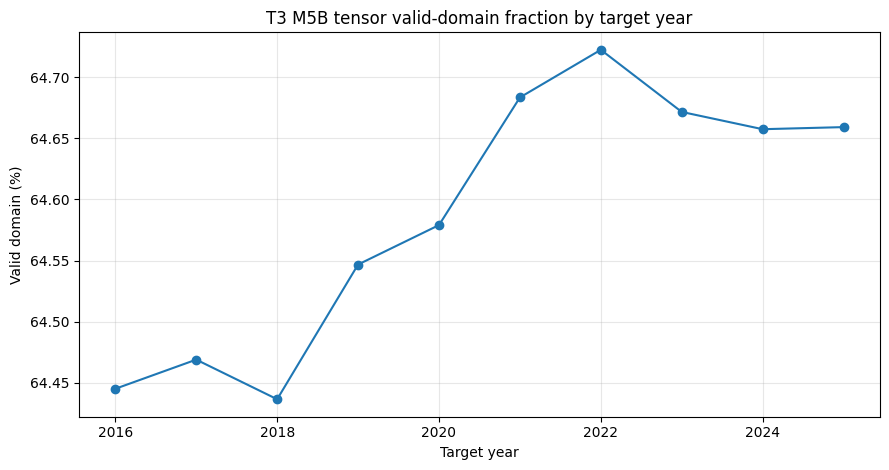

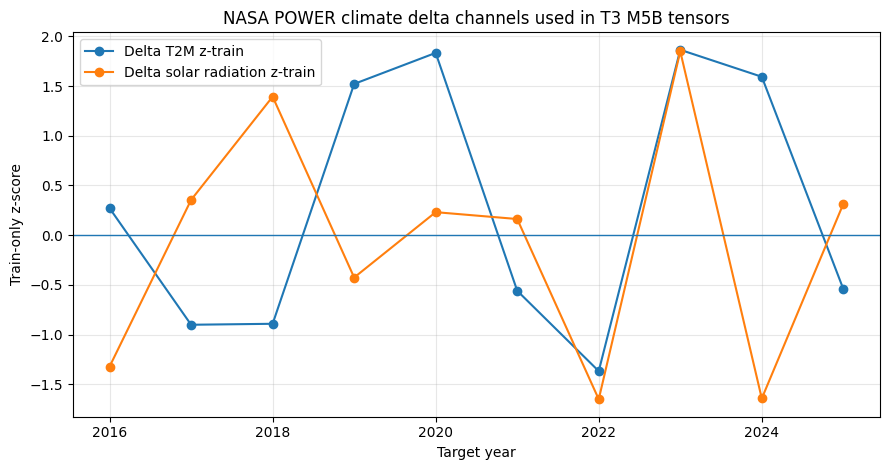

Figures saved:


,figure,path,description
0,06_tensor_valid_fraction_T3_M5B_2016_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Valid fraction of the full-domain T3 M5B tenso...
1,06_tensor_climate_delta_channels_T3_M5B_2016_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Train-only z-scored NASA POWER climate delta c...


Summary JSON saved: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/06_tensor_construction_summary_2016_2025.json
Bitácora saved    : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/06_tensor_construction_2016_2025/bitacora_06_tensor_construction_2016_2025.md
{
  "module": "06_tensor_construction",
  "product_name": "T3_M5B_spectral_nasa_power",
  "created_at": "2026-06-23T20:57:53.294360",
  "project_dir": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling",
  "operational_period": "2013-2025",
  "target_years": [
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024,
    2025
  ],
  "splits": {
    "train": [
      2016,
      2017,
      2018,
      2019
    ],
    "validation": [
      2020,
      2021,
      2022
    ],
    "test": [
      2023,
      2024,
      2025
    ]
  },
  "input_sources": {
    "normalized_ras

In [10]:
# ============================================================
# CELL 10 — Figures and final documentation outputs
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = manifest_df.sort_values("target_year")
ax.plot(plot_df["target_year"], plot_df["valid_fraction"] * 100, marker="o")
ax.set_title("T3 M5B tensor valid-domain fraction by target year")
ax.set_xlabel("Target year")
ax.set_ylabel("Valid domain (%)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path_1 = DOC06_FIG_DIR / "06_tensor_valid_fraction_T3_M5B_2016_2025.png"
fig.savefig(fig_path_1, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
clim_plot = climate_df.sort_values("target_year")
ax.plot(clim_plot["target_year"], clim_plot[CLIMATE_RAW_TO_Z["delta_t2m_mean_Y_minus_Yminus1"]], marker="o", label="Delta T2M z-train")
ax.plot(clim_plot["target_year"], clim_plot[CLIMATE_RAW_TO_Z["delta_solar_radiation_mean_Y_minus_Yminus1"]], marker="o", label="Delta solar radiation z-train")
ax.axhline(0, linewidth=1)
ax.set_title("NASA POWER climate delta channels used in T3 M5B tensors")
ax.set_xlabel("Target year")
ax.set_ylabel("Train-only z-score")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_path_2 = DOC06_FIG_DIR / "06_tensor_climate_delta_channels_T3_M5B_2016_2025.png"
fig.savefig(fig_path_2, dpi=160)
plt.show()

figures_manifest_df = pd.DataFrame([
    {"figure": fig_path_1.name, "path": str(fig_path_1), "description": "Valid fraction of the full-domain T3 M5B tensor mask by target year."},
    {"figure": fig_path_2.name, "path": str(fig_path_2), "description": "Train-only z-scored NASA POWER climate delta channels used in the M5B tensors."},
])
figures_manifest_path = DOC06_DIR / "06_tensor_figures_manifest_T3_M5B_2016_2025.csv"
figures_manifest_df.to_csv(figures_manifest_path, index=False)

summary = {
    "module": "06_tensor_construction",
    "product_name": "T3_M5B_spectral_nasa_power",
    "created_at": datetime.now().isoformat(),
    "project_dir": str(PROJECT_DIR),
    "operational_period": "2013-2025",
    "target_years": TARGET_YEARS,
    "splits": SPLITS,
    "input_sources": {
        "normalized_rasters": str(NORMALIZED_DIR),
        "nasa_power_selected_climate_inputs": str(CLIMATE_SELECTED_CSV),
        "model_domain_reference": str(MODEL_DOMAIN_REFERENCE),
    },
    "output_sources": {
        "tensor_npz_dir": str(TENSOR_NPZ_DIR),
        "valid_mask_dir": str(TENSOR_MASK_DIR),
        "documentation_dir": str(DOC06_DIR),
        "figures_dir": str(DOC06_FIG_DIR),
    },
    "tensor_design": {
        "X_shape_per_year": "height × width × 20",
        "y_shape_per_year": "height × width × 1",
        "mask_shape_per_year": "height × width × 1",
        "n_spectral_channels": len(SPECTRAL_CHANNEL_NAMES),
        "n_climate_channels": len(CLIMATE_CHANNEL_NAMES),
        "n_total_channels": len(CHANNEL_NAMES),
        "spectral_variables": SPECTRAL_VARIABLES,
        "temporal_lags": ["Y-3", "Y-2", "Y-1"],
        "climate_variables_raw": CLIMATE_VARIABLES_RAW,
        "climate_variables_channel_names": CLIMATE_CHANNEL_NAMES,
        "target": "LST_norm_zscore_train_only",
        "mask_definition": "valid target LST and all valid spectral antecedent channels",
    },
    "climate_methodological_note": "NASA POWER predictors are annual regional descriptors associated with the model-domain centroid. They are z-scored using train years only and replicated spatially as constant layers for tensor compatibility. They must not be interpreted as pixel-wise climate rasters.",
    "github_upload_policy": {
        "upload_to_data_tensors": [p.name for p in [channel_schema_path, climate_prepared_path, climate_scaler_path, preflight_path, manifest_path, qc_path, reload_path, summary_by_split_path, figures_manifest_path]],
        "do_not_upload": ["*.npz full-domain tensors", "valid model mask GeoTIFFs", "heavy raster/model outputs"],
    },
    "quality_control": {
        "n_tensors": int(len(manifest_df)),
        "all_tensors_have_20_channels": bool((manifest_df["n_channels"] == 20).all()),
        "any_nan_X": bool(manifest_df["has_nan_X"].any()),
        "any_nan_y": bool(manifest_df["has_nan_y"].any()),
        "mean_valid_fraction": float(manifest_df["valid_fraction"].mean()),
        "min_valid_fraction": float(manifest_df["valid_fraction"].min()),
        "max_valid_fraction": float(manifest_df["valid_fraction"].max()),
    },
}

summary_path = DOC06_DIR / "06_tensor_construction_summary_2016_2025.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

bitacora_path = DOC06_DIR / "bitacora_06_tensor_construction_2016_2025.md"
bitacora_text = f"""# Bitácora — Módulo 06: Construcción de tensores T3 M5B con NASA POWER

**Proyecto:** Barranquilla_LST_2013_2026_Modeling
**Módulo:** 06
**Notebook:** 06_tensor_construction.ipynb
**Producto:** T3_M5B_spectral_nasa_power
**Fecha:** {summary['created_at']}
**Estado:** Ejecutado correctamente si todas las validaciones finales fueron aprobadas.

## Objetivo

Construir tensores full-domain para la formulación M5B, integrando antecedentes espectrales Landsat T3 y dos descriptores climáticos interanuales NASA POWER.

## Formulación temporal

Para cada año objetivo Y se usaron tres años antecedentes:

```text
Y-3, Y-2, Y-1 → Y
```

## Canales de entrada

```text
18 canales espectrales = 3 años antecedentes × 6 índices
 2 canales climáticos  = deltas NASA POWER z-score train-only
20 canales totales
```

Variables espectrales:

```text
{', '.join(SPECTRAL_VARIABLES)}
```

Variables climáticas incorporadas:

```text
{CLIMATE_VARIABLES_RAW[0]}
{CLIMATE_VARIABLES_RAW[1]}
```

## Nota metodológica sobre NASA POWER

Los predictores NASA POWER no son campos climáticos rasterizados píxel a píxel. Son descriptores climáticos anuales/regionales asociados al centroide del dominio de modelación. Se expanden espacialmente como capas constantes únicamente para compatibilidad con la arquitectura convolucional.

## Salidas principales

Tensores NPZ:

```text
{TENSOR_NPZ_DIR}
```

Máscaras válidas:

```text
{TENSOR_MASK_DIR}
```

Reportes livianos para GitHub:

```text
{DOC06_DIR}
```

Figuras diagnósticas:

```text
{DOC06_FIG_DIR}
```

## Política GitHub

Subir a GitHub únicamente los CSV/JSON/MD y figuras ligeras. No subir los archivos `.npz` ni máscaras GeoTIFF si son pesados.
"""
with open(bitacora_path, "w", encoding="utf-8") as f:
    f.write(bitacora_text)

print("Figures saved:")
display(figures_manifest_df)
print("Summary JSON saved:", summary_path)
print("Bitácora saved    :", bitacora_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))


In [11]:
# ============================================================
# CELL 11 — Final closure checks
# ============================================================

expected_files = [
    channel_schema_path,
    climate_prepared_path,
    climate_scaler_path,
    preflight_path,
    manifest_path,
    qc_path,
    reload_path,
    summary_by_split_path,
    figures_manifest_path,
    summary_path,
    bitacora_path,
]

missing_outputs = [str(p) for p in expected_files if not Path(p).exists()]
if missing_outputs:
    raise RuntimeError("Missing expected documentation outputs:\n" + "\n".join(missing_outputs))

if len(manifest_df) != len(TARGET_YEARS):
    raise RuntimeError("Unexpected number of tensor rows in manifest.")
if not (manifest_df["n_channels"] == 20).all():
    raise RuntimeError("At least one tensor does not have 20 channels.")
if manifest_df["has_nan_X"].any() or manifest_df["has_nan_y"].any():
    raise RuntimeError("NaNs detected in saved tensors.")

print("Módulo 06 completado correctamente.")
print("\nSubir a GitHub, carpeta data/tensors/:")
for p in expected_files:
    if p.suffix.lower() in [".csv", ".json", ".md"]:
        print(" -", p.name)

print("\nSubir a GitHub, carpeta docs/figures/tensors/:")
for p in [fig_path_1, fig_path_2]:
    print(" -", p.name)

print("\nNo subir a GitHub:")
print(" -", TENSOR_NPZ_DIR)
print(" -", TENSOR_MASK_DIR)


Módulo 06 completado correctamente.

Subir a GitHub, carpeta data/tensors/:
 - 06_tensor_channel_schema_T3_M5B_2016_2025.csv
 - 06_climate_inputs_prepared_T3_M5B_2016_2025.csv
 - 06_climate_scaler_train_only_T3_M5B_2016_2025.json
 - 06_tensor_input_file_inventory_T3_M5B_2016_2025.csv
 - 06_tensor_manifest_T3_M5B_2016_2025.csv
 - 06_tensor_qc_channel_statistics_T3_M5B_2016_2025.csv
 - 06_tensor_reload_validation_T3_M5B_2016_2025.csv
 - 06_tensor_summary_by_split_T3_M5B_2016_2025.csv
 - 06_tensor_figures_manifest_T3_M5B_2016_2025.csv
 - 06_tensor_construction_summary_2016_2025.json
 - bitacora_06_tensor_construction_2016_2025.md

Subir a GitHub, carpeta docs/figures/tensors/:
 - 06_tensor_valid_fraction_T3_M5B_2016_2025.png
 - 06_tensor_climate_delta_channels_T3_M5B_2016_2025.png

No subir a GitHub:
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inputs/tensors/T3_M5B_spectral_nasa_power/npz
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/06_model_inp